# Permutation Importance (PIMP) Demo: Waveform-5000

This notebook demonstrates the PIMP algorithm (Altmann et al., 2010,
[doi:10.1093/bioinformatics/btq134](https://doi.org/10.1093/bioinformatics/btq134))
applied to I-ROCKET on the waveform-5000 dataset.

PIMP provides statistically corrected feature importance by comparing
observed importance against a null distribution built from permuted
class labels. The result is a p-value for each feature, answering:
"Is this feature more important than expected by chance?"

By default, PIMP uses a RandomForestClassifier for the
importance computation rather than I-ROCKET's Ridge classifier.
Tree-based methods assign zero importance to uninformative features,
producing a meaningful null distribution. Ridge regularization
distributes weight across all correlated features, which causes
every feature to appear significant regardless of its true relevance.
The ROCKET convolutional transform is label-independent and is
computed once and reused across all permutations.

## Setup

In [1]:
import os
os.environ["OMP_DISPLAY_ENV"] = "FALSE"
os.environ["KMP_WARNINGS"] = "0"

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['svg.fonttype'] = 'none'
RANDOM_STATE = 42

## Load data

In [2]:
from sklearn.datasets import fetch_openml

waveform = fetch_openml(name='waveform-5000', version=1, as_frame=False)
X = waveform.data[:, :21].astype(np.float32)
y = waveform.target.astype(int)

print(f"Dataset: {X.shape[0]} instances x {X.shape[1]} timepoints")
print(f"Classes: {np.unique(y)}, counts: {np.bincount(y)}")

Dataset: 5000 instances x 21 timepoints
Classes: [0 1 2], counts: [1692 1653 1655]


## Fit I-ROCKET

In [3]:
import interp_rocket as IR

model = IR.InterpRocket(
    max_dilations_per_kernel=32,
    num_features=10000,
    random_state=RANDOM_STATE,
)
model.fit(X, y)

metrics = model.evaluate(X, y)
print(f"\nTraining accuracy: {metrics['accuracy']:.4f}")
print(f"Total features: {model.transform(X[:1]).shape[1]}")

InterpRocket.fit: 5000 instances × 21 timepoints
  Classes: [0 1 2]
  Fitting dilations (raw)...
  Fitting biases (raw): 588 biases across 2 dilations...
  Fitting dilations (diff)...
  Fitting biases (diff): 588 biases across 2 dilations...
  Transforming training data...
  Feature matrix: (5000, 4704)
  Standardizing features...
  Fitting RidgeClassifierCV...
  Training accuracy: 0.9402
  Selected alpha: 4832.9302

Training accuracy: 0.9402
Total features: 4704


## Run PIMP

We run 100 permutations to build the null distribution. Each
permutation shuffles the class labels, fits a
RandomForestClassifier on the same ROCKET feature matrix,
and extracts `feature_importances_`. The p-value for each feature
is the fraction of null importances that are at least as large as
the observed importance.

In [4]:
pimp = IR.permutation_importance_test(
    model, X, y,
    n_permutations=100,
    random_state=RANDOM_STATE,
)

PIMP: 100 permutations, 4704 features, classifier=RandomForestClassifier
  Permutation 25/100
  Permutation 50/100
  Permutation 75/100
  Permutation 100/100

  Significant features (p < 0.05): 317 / 4704
  Non-significant: 4387 / 4704


## Visualize PIMP results

The bar chart shows observed importance for the top features, colored
by significance (blue = significant at p < 0.05, gray = not
significant). Red markers show the 95th percentile of the null
distribution. The right panel shows the overall p-value distribution.

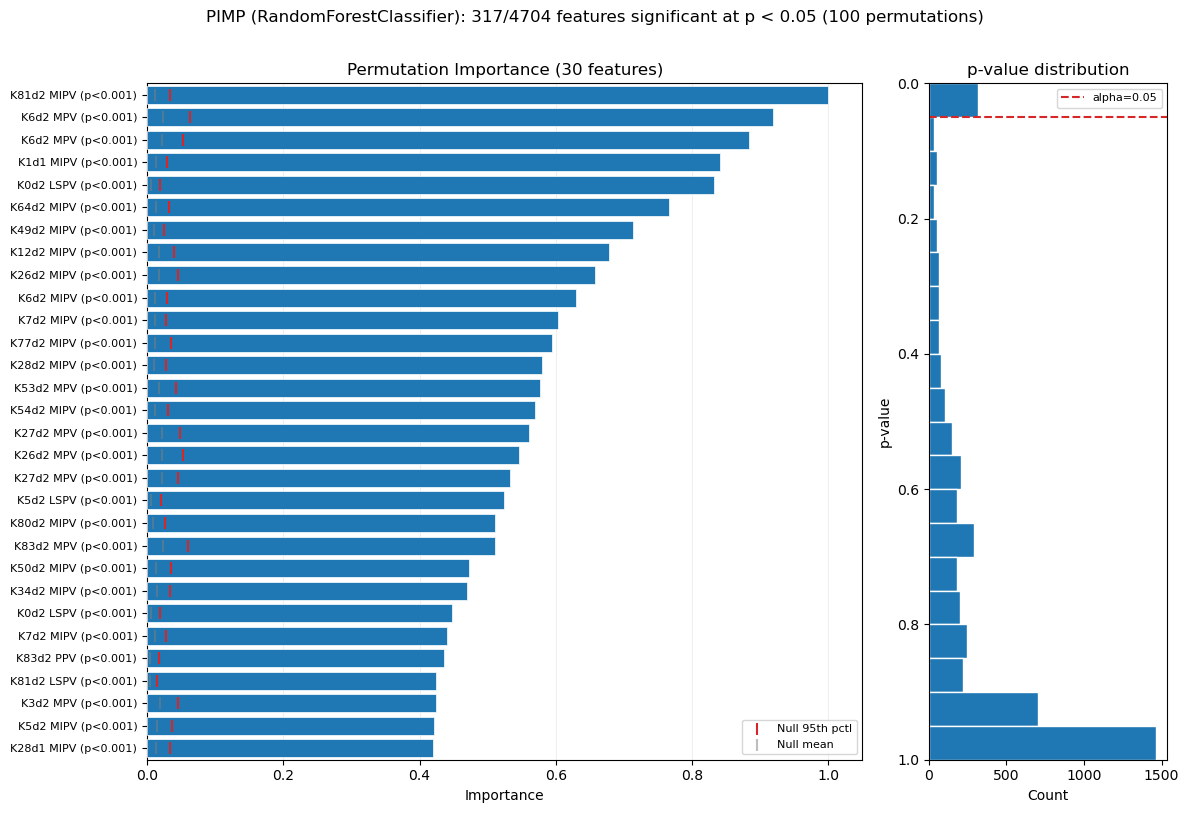

In [5]:
fig = IR.plot_permutation_importance(pimp, model=model, n_show=30)

## Extract significant features

Features with p < 0.05 are statistically more important than expected
under the null hypothesis of no class structure.

In [6]:
sig_features = np.where(pimp['significant_mask'])[0]
print(f"Significant features: {len(sig_features)} / {len(pimp['feature_mask'])}")
print(f"Non-significant: {len(pimp['feature_mask']) - len(sig_features)}")

# Decode the top significant features
sig_importance = pimp['observed_importance'][sig_features]
sig_order = np.argsort(-sig_importance)
top_sig = sig_features[sig_order[:20]]

print(f"\nTop 20 significant features:")
for fi in top_sig:
    info = model.decode_feature_index(int(fi))
    print(f"  F{fi:>5d}  K{info['kernel_index']:>2d} d={info['dilation']:>2d}  "
          f"{info['pooling_op']:>4s}  {info['representation']:>4s}  "
          f"imp={pimp['observed_importance'][fi]:.4f}  "
          f"p={pimp['p_values'][fi]:.3f}")

Significant features: 317 / 4704
Non-significant: 4387

Top 20 significant features:
  F 2314  K81 d= 2  MIPV   raw  imp=1.0000  p=0.000
  F 1105  K 6 d= 2   MPV   raw  imp=0.9186  p=0.000
  F 1113  K 6 d= 2   MPV   raw  imp=0.8833  p=0.000
  F   22  K 1 d= 1  MIPV   raw  imp=0.8414  p=0.000
  F 1011  K 0 d= 2  LSPV   raw  imp=0.8325  p=0.000
  F 2034  K64 d= 2  MIPV   raw  imp=0.7667  p=0.000
  F 1802  K49 d= 2  MIPV   raw  imp=0.7139  p=0.000
  F 1210  K12 d= 2  MIPV   raw  imp=0.6774  p=0.000
  F 1438  K26 d= 2  MIPV   raw  imp=0.6579  p=0.000
  F 1114  K 6 d= 2  MIPV   raw  imp=0.6290  p=0.000
  F 1122  K 7 d= 2  MIPV   raw  imp=0.6036  p=0.000
  F 2242  K77 d= 2  MIPV   raw  imp=0.5950  p=0.000
  F 1458  K28 d= 2  MIPV   raw  imp=0.5793  p=0.000
  F 1861  K53 d= 2   MPV   raw  imp=0.5774  p=0.000
  F 1874  K54 d= 2  MIPV   raw  imp=0.5688  p=0.000
  F 1441  K27 d= 2   MPV   raw  imp=0.5602  p=0.000
  F 1429  K26 d= 2   MPV   raw  imp=0.5466  p=0.000
  F 1449  K27 d= 2   MPV   raw 

## Compare PIMP with Feature Stability Analysis

Both methods identify robust features, but from different angles.
PIMP tests whether each feature's importance exceeds chance.
FSA tests whether each feature is consistently important across
data splits. Features that pass both tests are the most trustworthy.

In [7]:
# Run feature stability analysis
stability = IR.cv_feature_stability(X, y, n_repeats=5, n_folds=5, n_top=50)
stable_features = IR.get_stable_features(stability, threshold=0.8)

# Overlap
pimp_set = set(sig_features)
fsa_set = set(stable_features)
overlap = pimp_set & fsa_set

print(f"\nPIMP significant: {len(pimp_set)}")
print(f"FSA stable (>=80%): {len(fsa_set)}")
print(f"Overlap: {len(overlap)}")
print(f"FSA features also significant by PIMP: "
      f"{len(overlap)}/{len(fsa_set)} "
      f"({100*len(overlap)/max(len(fsa_set),1):.0f}%)")

CV feature stability: 5x5 folds, tracking top 50 features per fold
  Round 1/5: 103 features appeared in every round so far
  Round 2/5: 84 features appeared in every round so far
  Round 3/5: 73 features appeared in every round so far
  Round 4/5: 68 features appeared in every round so far
  Round 5/5: 68 features appeared in every round so far

  Features in ALL folds:  15
  Features in ≥80% folds: 25
  Features in NO folds:   4514
Stable features (≥80% of 25 folds): 25

PIMP significant: 317
FSA stable (>=80%): 25
Overlap: 10
FSA features also significant by PIMP: 10/25 (40%)


## Temporal importance using PIMP-significant features

We can use PIMP-significant features as an alternative feature mask
for all downstream I-ROCKET visualizations.

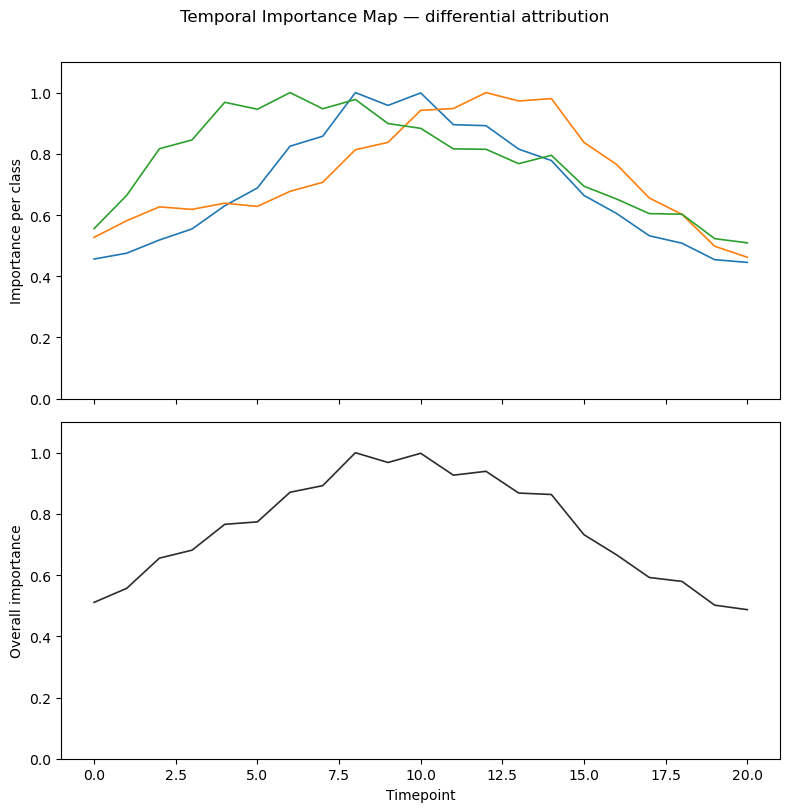

In [8]:
fig, imp = model.plot_temporal_importance(
    X, y, n_examples=100,
    feature_mask=sig_features,
    figsize=(8, 8),
)

## Receptive field diagram using PIMP-significant features

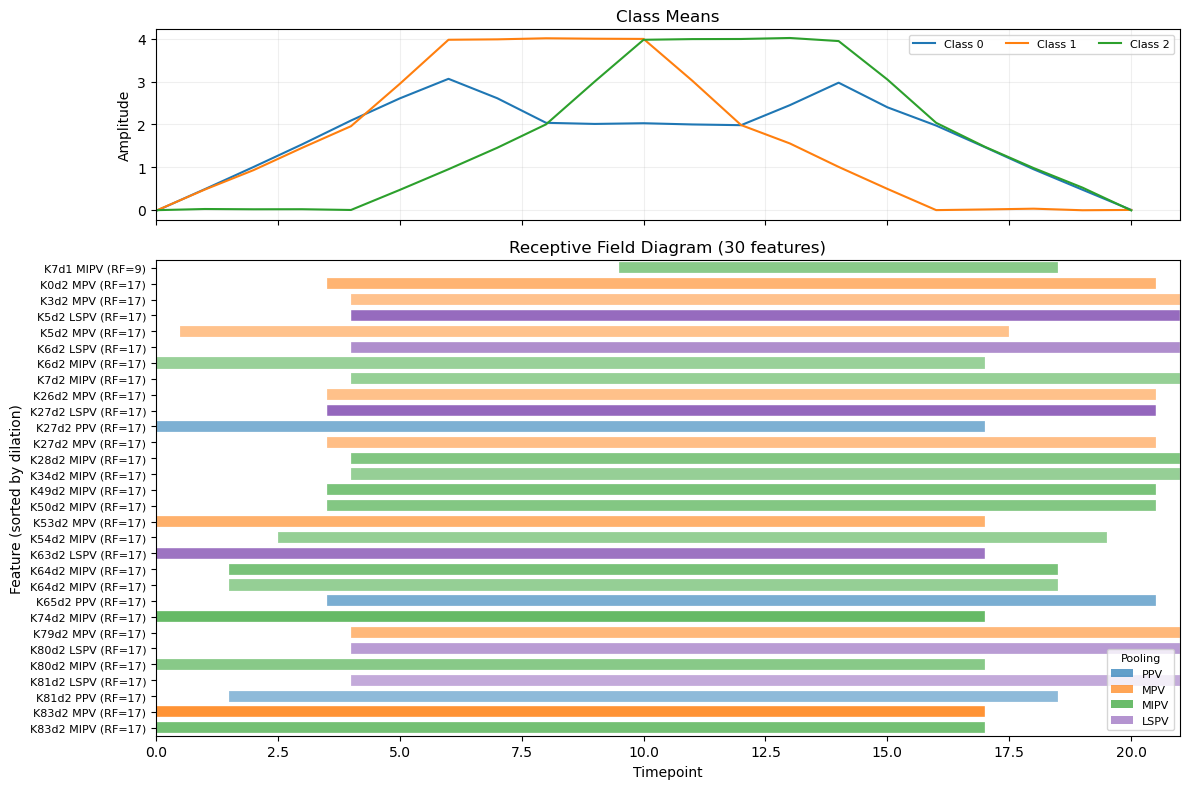

In [9]:
# Use the top 50 significant features by importance for a readable plot
top_50_sig = sig_features[sig_order[:50]]
fig = IR.plot_receptive_field_diagram(model, X, y, feature_mask=top_50_sig)

## Summary

PIMP provides a complementary approach to feature selection:

* **FSA** identifies features that are *consistently* important across data splits
* **PIMP** identifies features that are *significantly* more important than chance
* Features passing both criteria form the most robust interpretable set